<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearning/blob/master/DeepLearning/6_pytorch_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Understanding PyTorch — A Complete Guided Tour

**Goal:** By the end of this notebook, you will be comfortable *thinking* in PyTorch. You'll understand what tensors are, how to manipulate them, and how PyTorch's automatic differentiation engine (`autograd`) works — the single most important idea that makes training neural networks possible.

**What this notebook is NOT:** We won't build or train a neural network here. That's the *next* step. Right now, we're learning the *language* — the tool — so that when we do build networks, nothing feels like magic.

---

### The Big Picture: Why PyTorch?

Imagine you're an architect. Before you design a skyscraper, you need to learn your drafting tools — your ruler, your compass, your CAD software. PyTorch is the "CAD software" of deep learning. It gives us:

1. **Tensors** — the universal data container (like NumPy arrays, but supercharged)
2. **GPU acceleration** — run computations on graphics cards for massive speedups
3. **Automatic differentiation** — PyTorch computes gradients *for you*, which is the engine behind all learning

Let's explore each of these, one at a time.


---

## Part 1: Tensors — The Building Block of Everything

### What is a tensor?

A **tensor** is just a container for numbers — like a box that can hold data in different shapes.

You already know tensors by other names:

| Shape | Math name | Everyday example | PyTorch |
|-------|-----------|-------------------|---------|
| A single number | Scalar | Temperature: `22.5` | `torch.tensor(22.5)` |
| A list of numbers | Vector | Today's hourly temperatures: `[20, 21, 22, ...]` | `torch.tensor([20, 21, 22])` |
| A grid of numbers | Matrix | A spreadsheet with rows and columns | `torch.randn(3, 4)` |
| A cube (or higher) of numbers | 3D+ tensor | A color image (height × width × 3 colors) | `torch.randn(100, 100, 3)` |

**Key insight:** Tensors are NumPy arrays' cooler cousin. They can do everything NumPy arrays do, *plus* they can live on a GPU and track gradients.


### 1.1 Creating Tensors — Many Ways to Fill a Box

Let's start by making some tensors. There are many ways, each useful in different situations.


In [ ]:
import torch
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 1: From a Python list (you specify exact values)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
a = torch.tensor([1, 2, 3, 4])
print("From a list:        ", a)

b = torch.tensor([[1, 2, 3],
                   [4, 5, 6]])
print("From a nested list: ")
print(b)
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 2: Filled with specific values (useful for initialization)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
zeros = torch.zeros(3, 4)       # 3 rows, 4 columns, all zeros
ones  = torch.ones(2, 3)        # 2 rows, 3 columns, all ones
full  = torch.full((2, 2), 7.0) # 2×2, all sevens

print("Zeros (3×4):")
print(zeros)
print("\nOnes (2×3):")
print(ones)
print("\nFull of 7s (2×2):")
print(full)


PyTorch version: 2.10.0

From a list:         tensor([1, 2, 3, 4])
From a nested list: 
tensor([[1, 2, 3],
        [4, 5, 6]])

Zeros (3×4):
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Ones (2×3):
tensor([[1., 1., 1.],
        [1., 1., 1.]])

Full of 7s (2×2):
tensor([[7., 7.],
        [7., 7.]])


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 3: Random tensors (you'll use these A LOT)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# torch.rand  → uniform random numbers between 0 and 1
# torch.randn → random numbers from a "normal distribution" (bell curve, mean=0, std=1)
# torch.randint → random integers

uniform = torch.rand(2, 3)       # Each value between 0 and 1
normal  = torch.randn(2, 3)      # Each value from bell curve (can be negative!)
ints    = torch.randint(0, 10, (2, 3))  # Random integers from 0 to 9

print("Uniform random [0, 1):")
print(uniform)
print("\nNormal random (bell curve):")
print(normal)
print("\nRandom integers [0, 10):")
print(ints)


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 4: Sequences (like Python's range())
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

r = torch.arange(0, 10, 2)        # start=0, stop=10, step=2
print("arange(0, 10, 2):", r)

ls = torch.linspace(0, 1, 5)      # 5 evenly spaced points from 0 to 1
print("linspace(0, 1, 5):", ls)


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 5: From NumPy (bidirectional conversion)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

np_array = np.array([10, 20, 30])
from_numpy = torch.from_numpy(np_array)
print("NumPy →  Tensor:", from_numpy)

back_to_numpy = from_numpy.numpy()
print("Tensor → NumPy: ", back_to_numpy)

# ⚠️ IMPORTANT: They share memory! Changing one changes the other.
np_array[0] = 999
print("\nAfter changing NumPy array[0] to 999:")
print("  NumPy array:", np_array)
print("  Tensor:     ", from_numpy, "  ← also changed!")
print("\nThis is a FEATURE, not a bug — it avoids copying large arrays.")
print("If you want an independent copy, use: torch.tensor(np_array)  (not from_numpy)")


### 1.2 Every Tensor Has Three Key Properties

Every tensor carries three pieces of metadata that you'll check constantly:

| Property | What it tells you | Why you care |
|----------|-------------------|-------------|
| `.shape` (or `.size()`) | The dimensions — how many rows, columns, etc. | Matrix multiplication requires matching shapes |
| `.dtype` | The type of numbers stored (float32, int64, etc.) | Mixing types causes errors |
| `.device` | Where the tensor lives (CPU or GPU) | Tensors on different devices can't interact |

Think of it like a shipping box: the **shape** is the box dimensions, the **dtype** is what's inside (books vs. electronics), and the **device** is which warehouse it's stored in.


In [ ]:
t = torch.randn(3, 4, 5)

print("Shape:", t.shape)          # torch.Size([3, 4, 5])
print("  - Dimension 0 has size:", t.shape[0])  # 3
print("  - Dimension 1 has size:", t.shape[1])  # 4
print("  - Dimension 2 has size:", t.shape[2])  # 5
print("  - Number of dimensions:", t.ndim)       # 3 (also called "rank")
print("  - Total elements:      ", t.numel())    # 3 * 4 * 5 = 60

print("\nDtype:", t.dtype)         # torch.float32 (the default)
print("Device:", t.device)        # cpu (the default)


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Controlling dtype at creation time
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# By default, torch.tensor([1, 2, 3]) creates int64 (because the inputs are integers)
# But torch.tensor([1.0, 2.0, 3.0]) creates float32 (because the inputs are floats)

int_tensor   = torch.tensor([1, 2, 3])
float_tensor = torch.tensor([1.0, 2.0, 3.0])

print("From integers:", int_tensor.dtype)    # torch.int64
print("From floats:  ", float_tensor.dtype)  # torch.float32

# You can force a specific type:
forced = torch.tensor([1, 2, 3], dtype=torch.float32)
print("\nForced float32:", forced, "| dtype:", forced.dtype)

# Or convert later:
converted = int_tensor.float()   # shorthand for .to(torch.float32)
print("Converted:     ", converted, "| dtype:", converted.dtype)

# Common dtypes you'll see:
print("\n📋 Common dtypes:")
print("  torch.float32 (default for floats) — used for model weights & data")
print("  torch.float64 (double precision)   — rarely needed in deep learning")
print("  torch.int64   (default for ints)   — used for labels/indices")
print("  torch.bool                         — used for masks")


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Why dtype matters: a common trap
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

a = torch.tensor([1, 2, 3])            # int64
b = torch.tensor([1.5, 2.5, 3.5])      # float32

# This works — PyTorch auto-promotes int to float
result = a + b
print("int + float =", result, "| dtype:", result.dtype)

# But some operations REQUIRE float tensors:
try:
    torch.mean(a)  # mean of integers? That should be a float...
except RuntimeError as e:
    print(f"\ntorch.mean(int_tensor) fails: {e}")
    print("Fix: use a.float().mean() or a.to(torch.float32).mean()")
    print("Result:", a.float().mean())


### 1.3 Devices — Where Your Tensor Lives

PyTorch can run on:

- **CPU** — your regular processor (always available)
- **CUDA** — NVIDIA GPUs (much faster for large computations)
- **MPS** — Apple Silicon GPUs (M1/M2/M3 Macs)

**The Golden Rule:** Tensors on different devices **cannot** interact. You must move them to the same device first.

Think of it like two people in different cities trying to work on the same whiteboard — one of them has to travel first.


In [ ]:
# What's available on this machine?
print("CUDA (NVIDIA GPU) available:", torch.cuda.is_available())
print("MPS (Apple GPU) available:  ", torch.backends.mps.is_available())

# Pick the best available device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"\nUsing device: {device}")

# Create a tensor on CPU (default)
cpu_tensor = torch.randn(3)
print(f"\ncpu_tensor lives on: {cpu_tensor.device}")

# Move it to our best device
gpu_tensor = cpu_tensor.to(device)
print(f"gpu_tensor lives on: {gpu_tensor.device}")

# Move it back
back_on_cpu = gpu_tensor.cpu()  # shorthand for .to('cpu')
print(f"back_on_cpu lives on: {back_on_cpu.device}")


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# The device mismatch error (you WILL see this)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

if str(device) != "cpu":
    a_cpu = torch.tensor([1.0, 2.0, 3.0])
    b_gpu = torch.tensor([4.0, 5.0, 6.0]).to(device)

    try:
        c = a_cpu + b_gpu
    except RuntimeError as e:
        print(f"❌ Device mismatch error:\n   {e}")
        print(f"\n✅ Fix: move both to the same device first")
        c = a_cpu.to(device) + b_gpu
        print(f"   Result: {c}")
else:
    print("(Only one device available — CPU — so no mismatch possible on this machine)")
    print("But on a GPU machine, adding a CPU tensor + GPU tensor would crash!")


---

## Part 2: Tensor Operations — Doing Math

Now that we can create tensors, let's do things with them. This is where tensors start feeling like supercharged NumPy arrays.

### 2.1 Element-wise Operations

These apply an operation to **every element independently** — like applying a formula to every cell in a spreadsheet.


In [ ]:
a = torch.tensor([1.0, 2.0, 3.0, 4.0])
b = torch.tensor([10.0, 20.0, 30.0, 40.0])

print("a:", a)
print("b:", b)
print()

# Arithmetic — element by element
print("a + b  =", a + b)       # [11, 22, 33, 44]
print("a - b  =", a - b)       # [-9, -18, -27, -36]
print("a * b  =", a * b)       # [10, 40, 90, 160]  — NOT matrix multiply!
print("a / b  =", a / b)       # [0.1, 0.1, 0.1, 0.1]
print("a ** 2 =", a ** 2)      # [1, 4, 9, 16]

# These are all equivalent:
# a + b  ↔  torch.add(a, b)
# a * b  ↔  torch.mul(a, b)
# You'll usually use the operator (+, *, etc.) — it's cleaner.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Useful element-wise functions
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

print("x:         ", x)
print("abs(x):    ", torch.abs(x))           # absolute value
print("x.clamp(0):", x.clamp(min=0))         # ReLU! (replace negatives with 0)
print("exp(x):    ", torch.exp(x).round())   # e^x
print("sqrt(|x|): ", torch.sqrt(torch.abs(x)))

# Comparisons (return boolean tensors)
print("\nx > 0:  ", x > 0)
print("x == 0: ", x == 0)


### 2.2 Reduction Operations — Summarizing a Tensor into Fewer Numbers

Reductions **collapse** a dimension. Think of it as summarizing a column in a spreadsheet.


In [ ]:
t = torch.tensor([[1.0, 2.0, 3.0],
                   [4.0, 5.0, 6.0]])

print("Tensor:")
print(t)
print(f"Shape: {t.shape}  (2 rows × 3 columns)")

print("\n--- Reduce ALL elements to a single number ---")
print("Sum of all:  ", t.sum().item())       # 21.0
print("Mean of all: ", t.mean().item())      # 3.5
print("Max of all:  ", t.max().item())       # 6.0
print("Min of all:  ", t.min().item())       # 1.0

print("\n--- Reduce along a specific dimension ---")
print("Sum along dim=0 (collapse rows → one row):", t.sum(dim=0))     # [5, 7, 9]
print("Sum along dim=1 (collapse cols → one col):", t.sum(dim=1))     # [6, 15]
print("Mean along dim=0:", t.mean(dim=0))
print("Mean along dim=1:", t.mean(dim=1))

# .item() extracts a Python number from a scalar tensor
scalar = torch.tensor(42.0)
print(f"\nscalar tensor: {scalar}  →  Python number: {scalar.item()}")
print("Use .item() when you need a plain Python float (e.g., for printing loss values)")


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# argmax / argmin — WHERE is the max/min?
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# These return the INDEX of the max/min value —
# hugely important for classification ("which class has the highest score?")

scores = torch.tensor([0.1, 0.05, 0.8, 0.05])
print("Scores:", scores)
print("argmax:", scores.argmax().item(), " ← index of highest score")
print("This means class", scores.argmax().item(), "is the prediction")

# With a matrix — argmax per row
score_matrix = torch.tensor([[0.1, 0.9],
                              [0.7, 0.3],
                              [0.4, 0.6]])
print("\nScore matrix (3 samples, 2 classes):")
print(score_matrix)
print("Predictions (argmax per row):", score_matrix.argmax(dim=1))
# → [1, 0, 1] — sample 0 → class 1, sample 1 → class 0, sample 2 → class 1


### 2.3 Reshaping — Same Data, Different Box

Reshaping changes *how the numbers are organized* without changing the numbers themselves. It's like rearranging books on a shelf — same books, different layout.

This is critical in deep learning because data often needs to change shape as it flows through a network (e.g., a 28×28 image needs to become a flat vector of 784 numbers).


In [ ]:
# Start with a 1D tensor
original = torch.arange(12)  # [0, 1, 2, ..., 11]
print("Original:", original)
print("Shape:   ", original.shape, "— 12 elements in a row")

# Reshape into different arrangements — SAME 12 numbers
as_matrix = original.view(3, 4)    # 3 rows × 4 columns
print("\n.view(3, 4):")
print(as_matrix)

as_matrix2 = original.view(4, 3)   # 4 rows × 3 columns
print("\n.view(4, 3):")
print(as_matrix2)

as_3d = original.view(2, 2, 3)     # 2 "pages" × 2 rows × 3 columns
print("\n.view(2, 2, 3):")
print(as_3d)

# The -1 trick: "figure out this dimension for me"
auto = original.view(3, -1)  # 3 rows, PyTorch computes columns = 12/3 = 4
print("\n.view(3, -1) — PyTorch figures out the -1:")
print(auto)
print("Shape:", auto.shape)


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Real-world example: flattening an image
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# A single grayscale image (1 channel × 28 pixels × 28 pixels)
image = torch.randn(1, 28, 28)
print("Image shape:", image.shape, "— 1 channel, 28×28 pixels")

# Flatten to a vector (for feeding into a neural network's first layer)
flat = image.view(-1)  # → 784 numbers
print("Flattened:  ", flat.shape, "— one long vector")

# A BATCH of 32 images
batch = torch.randn(32, 1, 28, 28)
print("\nBatch shape:", batch.shape, "— 32 images, each 1×28×28")

# Flatten each image, but keep the batch dimension
flat_batch = batch.view(32, -1)  # → (32, 784)
print("Flattened:  ", flat_batch.shape, "— 32 images, each 784-long")

# Even better — use batch.size(0) so it works for any batch size:
flat_batch = batch.view(batch.size(0), -1)
print("Same thing: ", flat_batch.shape)


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# view vs reshape vs flatten — what's the difference?
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

t = torch.arange(12)

# .view()    — reshapes, but requires the tensor to be "contiguous" in memory
#              (almost always is; fails with an error if not)
a = t.view(3, 4)

# .reshape() — same as view, but works even if tensor isn't contiguous
#              (may copy data if needed)
b = t.reshape(3, 4)

# .flatten() — shorthand for reshaping into 1D
c = a.flatten()

print("view(3,4):\n", a)
print("\nreshape(3,4):\n", b)
print("\nflatten():", c)

print("\n💡 Rule of thumb:")
print("   - Use .view() in most cases (it's faster, no copy)")
print("   - Use .reshape() if .view() throws a 'contiguous' error")
print("   - Use .flatten() when you want a 1D vector")


### 2.4 Indexing and Slicing — Picking Out Specific Numbers

Works just like NumPy — and if you know Python list indexing, most of this will feel natural.


In [ ]:
t = torch.tensor([[10, 20, 30, 40],
                   [50, 60, 70, 80],
                   [90,100,110,120]])

print("Full tensor:")
print(t)

# ━━━ Basic indexing ━━━
print("\n--- Single elements ---")
print("t[0, 0] =", t[0, 0].item())    # 10  — row 0, col 0
print("t[1, 2] =", t[1, 2].item())    # 70  — row 1, col 2
print("t[-1, -1]=", t[-1, -1].item())  # 120 — last row, last col

# ━━━ Slicing ━━━
print("\n--- Slicing (works like Python lists) ---")
print("t[0, :]  — first row:      ", t[0, :])     # [10, 20, 30, 40]
print("t[:, 0]  — first column:   ", t[:, 0])     # [10, 50, 90]
print("t[:2, :] — first 2 rows:\n", t[:2, :])
print("t[:, 1:3]— columns 1 and 2:\n", t[:, 1:3])


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Boolean indexing (masking) — very powerful!
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

scores = torch.tensor([85.0, 42.0, 91.0, 67.0, 73.0, 38.0])
print("Scores:", scores)

# Create a boolean mask
passing = scores >= 60
print("Passing (≥60)?", passing)

# Use the mask to select elements
print("Passing scores:", scores[passing])
print("Failing scores:", scores[~passing])   # ~ means NOT

# Count how many passed
print(f"\n{passing.sum().item():.0f} out of {len(scores)} passed")


### 2.5 Matrix Multiplication — The Heart of Neural Networks

**This is the single most important operation in deep learning.**

Every neural network layer does this: `output = input @ weights + bias`

The `@` operator (or `torch.matmul`) performs matrix multiplication. Let's make sure we understand it.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Matrix multiply: (m × n) @ (n × p) → (m × p)
# The "inner dimensions" must match!
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

A = torch.tensor([[1.0, 2.0],    # shape: (2, 3)
                   [3.0, 4.0]])

B = torch.tensor([[5.0, 6.0],    # shape: (2, 2)
                   [7.0, 8.0]])

result = A @ B   # (2×2) @ (2×2) → (2×2)
print("A:")
print(A)
print("\nB:")
print(B)
print("\nA @ B:")
print(result)

# Let's verify one element by hand:
# result[0,0] = A[0,0]*B[0,0] + A[0,1]*B[1,0] = 1*5 + 2*7 = 19 ✓
print(f"\nManual check: result[0,0] = {A[0,0]}×{B[0,0]} + {A[0,1]}×{B[1,0]} = {A[0,0]*B[0,0] + A[0,1]*B[1,0]}")


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Why this matters: a neural network layer in one line
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Imagine 4 data points, each with 3 features
data = torch.randn(4, 3)          # shape: (4, 3) — "4 samples, 3 features"

# A layer with 3 inputs and 5 neurons → weight matrix is (3, 5)
weights = torch.randn(3, 5)       # shape: (3, 5)
bias = torch.zeros(5)              # shape: (5,)

# The forward pass of one layer:
output = data @ weights + bias     # (4, 3) @ (3, 5) + (5,) → (4, 5)

print("Input shape: ", data.shape,    "  — 4 samples, 3 features each")
print("Weight shape:", weights.shape, "  — connects 3 inputs to 5 neurons")
print("Bias shape:  ", bias.shape,    "     — one bias per neuron")
print("Output shape:", output.shape,  "  — 4 samples, 5 outputs each")

print("\nThis single line IS a neural network layer!")
print("Everything else — nn.Linear, model architectures — is just a wrapper around this idea.")


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Shape mismatch errors (you'll see these often!)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

X = torch.randn(4, 3)   # 4×3
Y = torch.randn(4, 5)   # 4×5

try:
    bad = X @ Y   # (4,3) @ (4,5) — inner dimensions 3 ≠ 4!
except RuntimeError as e:
    print(f"❌ Shape mismatch: {e}")
    print(f"\n   X is {X.shape}, Y is {Y.shape}")
    print(f"   For X @ Y, we need X's last dim ({X.shape[1]}) == Y's first dim ({Y.shape[0]})")
    print(f"   3 ≠ 4 → crash!")
    print(f"\n   Fix: use X @ Y.T (transpose Y) → ({X.shape[0]},{X.shape[1]}) @ ({Y.shape[1]},{Y.shape[0]}) → works if 3==5? No.")
    print(f"   Or redesign Y to be (3, something)")


### 2.6 Broadcasting — When Shapes Don't Match (But It's OK)

Broadcasting is PyTorch's way of "stretching" a smaller tensor to match a larger one, so you can do operations between tensors of *different* shapes.

**Rules (simplified):**
1. Compare shapes from the right (last dimension first)
2. Dimensions match if they're equal OR one of them is 1
3. The size-1 dimension gets "stretched" (conceptually repeated)


In [ ]:
# ━━━ Example 1: Add a scalar to a matrix ━━━
m = torch.tensor([[1.0, 2.0, 3.0],
                   [4.0, 5.0, 6.0]])
print("Matrix + 10:")
print(m + 10)          # 10 is "broadcast" to every element
print()

# ━━━ Example 2: Add a vector to each row ━━━
row_bias = torch.tensor([100.0, 200.0, 300.0])  # shape: (3,)
print(f"Matrix shape: {m.shape},  bias shape: {row_bias.shape}")
print("Matrix + row_bias:")
print(m + row_bias)    # row_bias is broadcast across rows

# This is EXACTLY what "+ bias" does in a neural network layer:
# output = data @ weights + bias
# bias has shape (num_neurons,) and gets added to every sample in the batch
print()

# ━━━ Example 3: Add a column vector to each column ━━━
col_bias = torch.tensor([[10.0],
                          [20.0]])  # shape: (2, 1) — note the extra dimension!
print(f"Matrix shape: {m.shape},  col_bias shape: {col_bias.shape}")
print("Matrix + col_bias:")
print(m + col_bias)


### 2.7 In-Place Operations — Modifying Tensors Directly

Any operation ending with `_` (underscore) modifies the tensor **in place** — no new tensor is created.


In [ ]:
x = torch.tensor([1.0, 2.0, 3.0])
print("Original:", x)

# Normal operation — creates a new tensor, x is unchanged
y = x.add(5)
print("x.add(5):", y, " — new tensor")
print("x is unchanged:", x)

# In-place operation — modifies x directly
x.add_(5)
print("\nx.add_(5):", x, " — x itself changed!")

# More in-place examples:
x.zero_()              # set all to 0
print("x.zero_():", x)

x.fill_(42)            # set all to 42
print("x.fill_(42):", x)

x.clamp_(min=0)        # ReLU in-place
print("x.clamp_(min=0):", x)

print("\n💡 Convention: underscore suffix = in-place")
print("   .add() → new tensor    |    .add_() → modifies original")
print("   .mul() → new tensor    |    .mul_() → modifies original")
print("   .zero_(), .fill_(), .clamp_() — all in-place")
print("\n⚠️  Careful with autograd: in-place ops on tensors with")
print("    requires_grad=True can cause errors (more on this later)")


---

## Part 3: Autograd — PyTorch's Superpower

This is the **most important part** of this entire notebook.

### The Problem Autograd Solves

Training a neural network requires computing **gradients** — how much does the output change when we nudge each weight? With millions of weights, computing this by hand is impossible.

**Autograd** does it automatically. You write the forward computation (the math), and PyTorch figures out all the derivatives for you by tracing a **computation graph**.

### The Analogy: A Recipe and Its Adjustments

Imagine you're baking a cake:

1. You follow a recipe (the **forward pass**): mix flour, add sugar, bake at 180°C → cake
2. The cake is too sweet (the **loss** is high)
3. You ask: "How much should I reduce the sugar to make it less sweet?" (the **gradient**)

Autograd is like a smart assistant who watches you cook and can tell you exactly how each ingredient affected the final sweetness.

### Three Key Concepts

| Concept | What it means | PyTorch |
|---------|--------------|---------|
| **Track** | Tell PyTorch to watch this variable | `requires_grad=True` |
| **Compute** | Run your math forward | Normal operations (`+`, `*`, `@`, etc.) |
| **Differentiate** | Ask "how does the output depend on my variables?" | `.backward()` |


### 3.1 The Simplest Gradient — One Variable, One Output

Let's start with the simplest possible case: a single variable `x`, and a function `y = (x - 3)²`.

We know from calculus that `dy/dx = 2(x - 3)`. Let's verify PyTorch gets this right.


In [ ]:
# Step 1: Create a tensor and tell PyTorch to TRACK it
x = torch.tensor(5.0, requires_grad=True)
print("x =", x)
print("requires_grad:", x.requires_grad, "— PyTorch is watching this tensor")

# Step 2: Do some math (forward pass)
# PyTorch silently builds a computation graph as you compute
y = (x - 3) ** 2
print("\ny = (x - 3)² =", y.item())

# Step 3: Compute the gradient
# .backward() traces back through the graph and fills in .grad for every watched tensor
y.backward()

print("\n✅ dy/dx =", x.grad.item())
print("   Expected: 2*(x-3) = 2*(5-3) = 4.0")


x = tensor(5., requires_grad=True)
requires_grad: True — PyTorch is watching this tensor

y = (x - 3)² = 4.0

✅ dy/dx = 4.0
   Expected: 2*(x-3) = 2*(5-3) = 4.0


x:              grad_fn = None   ← leaf variable, nothing created it
step1 = x - 3:  grad_fn = <SubBackward0 object at 0x11f5648e0>   ← created by subtraction
step2 = step1²: grad_fn = <PowBackward0 object at 0x11f5648e0>   ← created by power



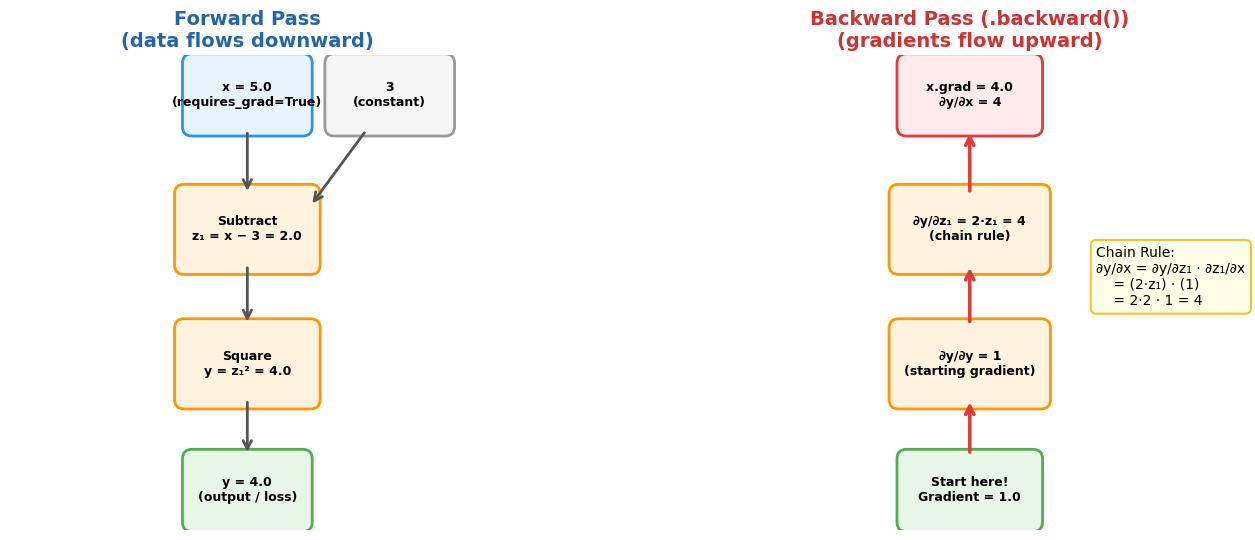

KEY INSIGHT:
  • Forward pass: you write the math, PyTorch records every operation
  • Backward pass: PyTorch replays the tape in reverse, applying the chain rule
  • The grad_fn on each tensor IS the recorded operation


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Let's VISUALIZE the computation graph
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# When you write y = (x - 3)², PyTorch secretly builds a graph
# of every operation. Let's draw it.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

x = torch.tensor(5.0, requires_grad=True)
step1 = x - 3       # SubBackward
step2 = step1 ** 2   # PowBackward

# Let's inspect what PyTorch recorded
print("x:              grad_fn =", x.grad_fn,      "  ← leaf variable, nothing created it")
print("step1 = x - 3:  grad_fn =", step1.grad_fn,  "  ← created by subtraction")
print("step2 = step1²: grad_fn =", step2.grad_fn,  "  ← created by power")
print()

# Now let's DRAW this graph
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5),
                          gridspec_kw={'width_ratios': [1, 1]})

# ────────────────────────────────────────
# LEFT: Forward pass (data flows DOWN)
# ────────────────────────────────────────
ax = axes[0]
ax.set_xlim(-1, 5)
ax.set_ylim(-0.5, 5.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Forward Pass\n(data flows downward)', fontsize=14, fontweight='bold', color='#2266AA')

# Node positions (x_pos, y_pos)
nodes = {
    'x':     (2, 5.0, f'x = 5.0\n(requires_grad=True)', '#E8F4FD', '#2196F3'),
    '3':     (3.8, 5.0, '3\n(constant)', '#F5F5F5', '#999999'),
    'sub':   (2, 3.3, 'Subtract\nz₁ = x − 3 = 2.0', '#FFF3E0', '#FF9800'),
    'pow':   (2, 1.6, 'Square\ny = z₁² = 4.0', '#FFF3E0', '#FF9800'),
    'y':     (2, 0.0, 'y = 4.0\n(output / loss)', '#E8F5E9', '#4CAF50'),
}

for key, (nx, ny, label, fill, edge) in nodes.items():
    w, h = (1.6, 0.9) if key in ('sub', 'pow') else (1.4, 0.8)
    shape = 'round' if key in ('sub', 'pow') else 'round'
    box = mpatches.FancyBboxPatch((nx - w/2, ny - h/2), w, h,
                                   boxstyle=f"round,pad=0.12",
                                   facecolor=fill, edgecolor=edge, linewidth=2)
    ax.add_patch(box)
    fontsize = 9 if key in ('sub', 'pow') else 9
    ax.text(nx, ny, label, ha='center', va='center', fontsize=fontsize, fontweight='bold')

# Arrows (forward)
arrow_kw = dict(arrowstyle='->', color='#555', lw=2, mutation_scale=15)
ax.annotate('', xy=(2, 3.75), xytext=(2, 4.55), arrowprops=arrow_kw)       # x → sub
ax.annotate('', xy=(2.8, 3.6), xytext=(3.5, 4.55), arrowprops=arrow_kw)    # 3 → sub
ax.annotate('', xy=(2, 2.1), xytext=(2, 2.85), arrowprops=arrow_kw)        # sub → pow
ax.annotate('', xy=(2, 0.45), xytext=(2, 1.15), arrowprops=arrow_kw)       # pow → y

# ────────────────────────────────────────
# RIGHT: Backward pass (gradients flow UP)
# ────────────────────────────────────────
ax = axes[1]
ax.set_xlim(-1, 5)
ax.set_ylim(-0.5, 5.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Backward Pass (.backward())\n(gradients flow upward)', fontsize=14, fontweight='bold', color='#CC3333')

nodes_bw = {
    'x':     (2, 5.0, f'x.grad = 4.0\n∂y/∂x = 4', '#FFEBEE', '#E53935'),
    'sub':   (2, 3.3, '∂y/∂z₁ = 2·z₁ = 4\n(chain rule)', '#FFF3E0', '#FF9800'),
    'pow':   (2, 1.6, '∂y/∂y = 1\n(starting gradient)', '#FFF3E0', '#FF9800'),
    'y':     (2, 0.0, 'Start here!\nGradient = 1.0', '#E8F5E9', '#4CAF50'),
}

for key, (nx, ny, label, fill, edge) in nodes_bw.items():
    w, h = (1.8, 0.9) if key in ('sub', 'pow') else (1.6, 0.8)
    box = mpatches.FancyBboxPatch((nx - w/2, ny - h/2), w, h,
                                   boxstyle=f"round,pad=0.12",
                                   facecolor=fill, edgecolor=edge, linewidth=2)
    ax.add_patch(box)
    ax.text(nx, ny, label, ha='center', va='center', fontsize=9, fontweight='bold')

# Arrows (backward — going UP)
arrow_bw = dict(arrowstyle='->', color='#E53935', lw=2.5, mutation_scale=15)
ax.annotate('', xy=(2, 1.15), xytext=(2, 0.45), arrowprops=arrow_bw)       # y → pow
ax.annotate('', xy=(2, 2.85), xytext=(2, 2.1), arrowprops=arrow_bw)        # pow → sub
ax.annotate('', xy=(2, 4.55), xytext=(2, 3.75), arrowprops=arrow_bw)       # sub → x

# Chain rule annotation
ax.text(3.6, 2.7, 'Chain Rule:\n∂y/∂x = ∂y/∂z₁ · ∂z₁/∂x\n    = (2·z₁) · (1)\n    = 2·2 · 1 = 4',
        fontsize=10, ha='left', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFFDE7', edgecolor='#FBC02D', linewidth=1.5))

plt.tight_layout()
plt.show()

print("KEY INSIGHT:")
print("  • Forward pass: you write the math, PyTorch records every operation")
print("  • Backward pass: PyTorch replays the tape in reverse, applying the chain rule")
print("  • The grad_fn on each tensor IS the recorded operation")


### Visualizing a More Realistic Graph

The simple `(x-3)²` graph had only 2 operations. In a real neural network layer, the graph looks more like this:

```
output = relu(w · x + b)
loss   = (output - target)²
```

Let's build this and visualize the full graph — this is essentially what happens inside **one neuron**.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# A mini neural network: one neuron with loss
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

w = torch.tensor(0.8, requires_grad=True)   # weight
b = torch.tensor(-0.2, requires_grad=True)  # bias
x_in = torch.tensor(2.0)                    # input (not learnable)
target = torch.tensor(1.0)                  # target (not learnable)

# Forward pass — each line creates a node in the graph
z = w * x_in        # 0.8 * 2.0 = 1.6
pre_act = z + b     # 1.6 + (-0.2) = 1.4
act = pre_act.clamp(min=0)  # ReLU: max(0, 1.4) = 1.4
diff = act - target # 1.4 - 1.0 = 0.4
loss = diff ** 2    # 0.4² = 0.16

print("Forward pass (watch the values flow):")
print(f"  w={w.item():.1f}, b={b.item():.1f}, x={x_in.item():.1f}, target={target.item():.1f}")
print(f"  z = w·x         = {z.item():.2f}")
print(f"  pre_act = z + b = {pre_act.item():.2f}")
print(f"  act = ReLU(pre) = {act.item():.2f}")
print(f"  diff = act - t  = {diff.item():.2f}")
print(f"  loss = diff²    = {loss.item():.4f}")

# Backward — fills in w.grad and b.grad
loss.backward()

print(f"\nGradients (computed by backward):")
print(f"  ∂loss/∂w = {w.grad.item():.4f}")
print(f"  ∂loss/∂b = {b.grad.item():.4f}")
print(f"\n  The gradient tells us:")
print(f"  • w should {'decrease' if w.grad > 0 else 'increase'} to reduce loss (grad {'> 0' if w.grad > 0 else '< 0'})")
print(f"  • b should {'decrease' if b.grad > 0 else 'increase'} to reduce loss (grad {'> 0' if b.grad > 0 else '< 0'})")


Forward pass (watch the values flow):
  w=0.8, b=-0.2, x=2.0, target=1.0
  z = w·x         = 1.60
  pre_act = z + b = 1.40
  act = ReLU(pre) = 1.40
  diff = act - t  = 0.40
  loss = diff²    = 0.1600

Gradients (computed by backward):
  ∂loss/∂w = 1.6000
  ∂loss/∂b = 0.8000

  The gradient tells us:
  • w should decrease to reduce loss (grad > 0)
  • b should decrease to reduce loss (grad > 0)


/var/folders/p6/6_nprx9x22s4njm57gzb34l40000gp/T/ipykernel_15815/2742324645.py:80: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p6/6_nprx9x22s4njm57gzb34l40000gp/T/ipykernel_15815/2742324645.py:80: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p6/6_nprx9x22s4njm57gzb34l40000gp/T/ipykernel_15815/2742324645.py:80: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu San

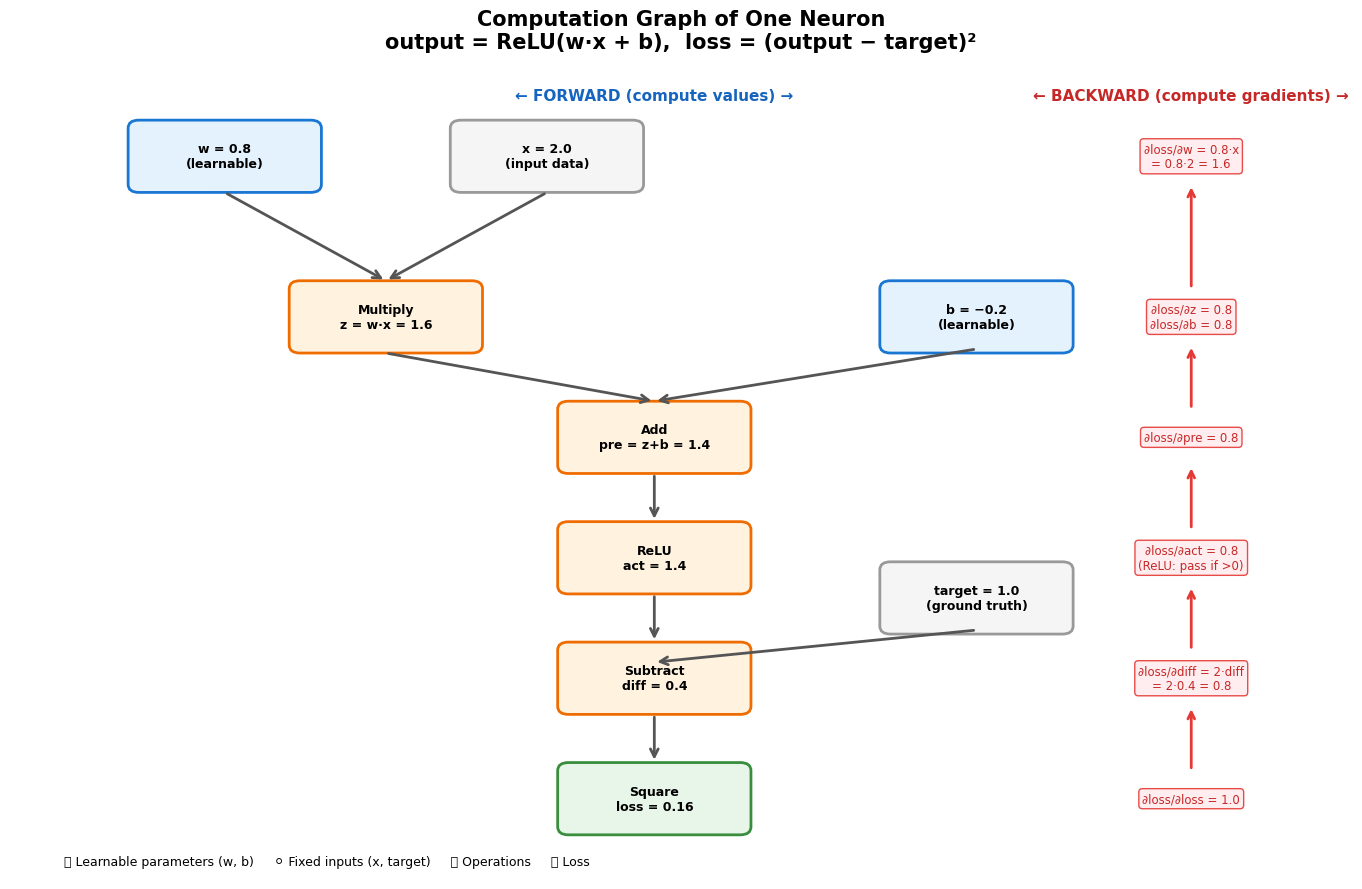

This graph is what PyTorch builds behind the scenes.
Every neural network — no matter how complex — is just a bigger version of this graph.
More layers = more operation nodes. More weights = more leaf nodes. Same idea.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Visualize the full computation graph for one neuron
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(-0.5, 12)
ax.set_ylim(-0.5, 9.5)
ax.axis('off')
ax.set_title('Computation Graph of One Neuron\noutput = ReLU(w·x + b),  loss = (output − target)²',
             fontsize=15, fontweight='bold', pad=20)

def draw_node(ax, x, y, text, color, edge_color, w=1.6, h=0.7):
    box = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                   boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor=edge_color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, fontweight='bold')

def draw_arrow(ax, x1, y1, x2, y2, color='#555', label='', lbl_offset=(0, 0)):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2, mutation_scale=14))
    if label:
        mx, my = (x1+x2)/2 + lbl_offset[0], (y1+y2)/2 + lbl_offset[1]
        ax.text(mx, my, label, fontsize=8, ha='center', va='center', color=color,
                fontstyle='italic')

# ── Leaf nodes (inputs) ──
draw_node(ax, 1.5, 8.5, 'w = 0.8\n(learnable)', '#E3F2FD', '#1976D2')
draw_node(ax, 4.5, 8.5, 'x = 2.0\n(input data)', '#F5F5F5', '#999')
draw_node(ax, 8.5, 6.5, 'b = −0.2\n(learnable)', '#E3F2FD', '#1976D2')
draw_node(ax, 8.5, 3.0, 'target = 1.0\n(ground truth)', '#F5F5F5', '#999')

# ── Operation nodes ──
draw_node(ax, 3.0, 6.5, 'Multiply\nz = w·x = 1.6', '#FFF3E0', '#EF6C00')
draw_node(ax, 5.5, 5.0, 'Add\npre = z+b = 1.4', '#FFF3E0', '#EF6C00')
draw_node(ax, 5.5, 3.5, 'ReLU\nact = 1.4', '#FFF3E0', '#EF6C00')
draw_node(ax, 5.5, 2.0, 'Subtract\ndiff = 0.4', '#FFF3E0', '#EF6C00')
draw_node(ax, 5.5, 0.5, 'Square\nloss = 0.16', '#E8F5E9', '#388E3C')

# ── Forward arrows ──
draw_arrow(ax, 1.5, 8.05, 3.0, 6.95)    # w → mul
draw_arrow(ax, 4.5, 8.05, 3.0, 6.95)    # x → mul
draw_arrow(ax, 3.0, 6.05, 5.5, 5.45)    # mul → add
draw_arrow(ax, 8.5, 6.1, 5.5, 5.45)     # b → add
draw_arrow(ax, 5.5, 4.55, 5.5, 3.95)    # add → relu
draw_arrow(ax, 5.5, 3.05, 5.5, 2.45)    # relu → sub
draw_arrow(ax, 8.5, 2.6, 5.5, 2.2)      # target → sub
draw_arrow(ax, 5.5, 1.55, 5.5, 0.95)    # sub → square

# ── Backward gradient labels (on the right side) ──
grad_info = [
    (10.5, 0.5,  '∂loss/∂loss = 1.0',       'Start'),
    (10.5, 2.0,  '∂loss/∂diff = 2·diff\n= 2·0.4 = 0.8', ''),
    (10.5, 3.5,  '∂loss/∂act = 0.8\n(ReLU: pass if >0)', ''),
    (10.5, 5.0,  '∂loss/∂pre = 0.8', ''),
    (10.5, 6.5,  '∂loss/∂z = 0.8\n∂loss/∂b = 0.8', ''),
    (10.5, 8.5,  '∂loss/∂w = 0.8·x\n= 0.8·2 = 1.6', ''),
]

for gx, gy, text, tag in grad_info:
    ax.text(gx, gy, text, fontsize=8.5, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#E53935', alpha=0.9),
            color='#C62828')

# Backward arrow column
for i in range(len(grad_info)-1):
    y1 = grad_info[i][1] + 0.35
    y2 = grad_info[i+1][1] - 0.35
    ax.annotate('', xy=(10.5, y2), xytext=(10.5, y1),
                arrowprops=dict(arrowstyle='->', color='#E53935', lw=2, mutation_scale=12))

# Labels
ax.text(5.5, 9.2, '← FORWARD (compute values) →', fontsize=11, ha='center', color='#1565C0', fontweight='bold')
ax.text(10.5, 9.2, '← BACKWARD (compute gradients) →', fontsize=11, ha='center', color='#C62828', fontweight='bold')

# Legend
ax.text(0, -0.2, '🔵 Learnable parameters (w, b)     ⚪ Fixed inputs (x, target)     🟠 Operations     🟢 Loss',
        fontsize=9, ha='left', va='top')

plt.tight_layout()
plt.show()

print("This graph is what PyTorch builds behind the scenes.")
print("Every neural network — no matter how complex — is just a bigger version of this graph.")
print("More layers = more operation nodes. More weights = more leaf nodes. Same idea.")


### 3.2 Gradients Accumulate — The #1 PyTorch Gotcha

**Critical rule:** Every time you call `.backward()`, the gradient gets **added** to whatever was already in `.grad`. It does NOT replace it.

This is by far the most common source of bugs for beginners. Let's see it in action.


In [ ]:
x = torch.tensor(5.0, requires_grad=True)

# First backward
y1 = (x - 3) ** 2
y1.backward()
print("After 1st backward: x.grad =", x.grad.item(), "  (correct: 4.0)")

# Second backward — WITHOUT zeroing the gradient
y2 = (x - 3) ** 2
y2.backward()
print("After 2nd backward: x.grad =", x.grad.item(), "  (WRONG! 4 + 4 = 8)")

# Third backward — still accumulating!
y3 = (x - 3) ** 2
y3.backward()
print("After 3rd backward: x.grad =", x.grad.item(), "  (4 + 4 + 4 = 12!)")

print("\n🐛 Bug! The gradient kept piling up.")
print("   Every training iteration would get a MORE WRONG gradient.")


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# The fix: ALWAYS zero gradients before backward()
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

x = torch.tensor(5.0, requires_grad=True)

for i in range(3):
    # Zero the gradient FIRST
    if x.grad is not None:
        x.grad.zero_()

    y = (x - 3) ** 2
    y.backward()
    print(f"Iteration {i+1}: x.grad = {x.grad.item()}  ✅ (always 4.0)")

print()
print("In a real training loop, this is done by:")
print("  optimizer.zero_grad()   ← zeros ALL model parameter gradients at once")
print("  loss.backward()        ← computes fresh gradients")
print("  optimizer.step()       ← updates weights using those gradients")


### 3.3 Gradients with Multiple Variables

In a neural network, you have thousands of parameters (weights and biases). `.backward()` computes the gradient with respect to **all** of them at once.


In [ ]:
# Two variables
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# A simple function of both
# y = (w*x + b - target)²  where x=3, target=10
x_val = 3.0
target = 10.0

prediction = w * x_val + b        # 2*3 + 1 = 7
loss = (prediction - target) ** 2  # (7 - 10)² = 9

print(f"w = {w.item()}, b = {b.item()}")
print(f"prediction = w*{x_val} + b = {prediction.item()}")
print(f"loss = (pred - target)² = ({prediction.item()} - {target})² = {loss.item()}")

loss.backward()

print(f"\n∂loss/∂w = {w.grad.item()}")
print(f"∂loss/∂b = {b.grad.item()}")

# Let's verify:
# loss = (w*3 + b - 10)²
# ∂loss/∂w = 2*(w*3 + b - 10) * 3 = 2*(7-10)*3 = -18
# ∂loss/∂b = 2*(w*3 + b - 10) * 1 = 2*(7-10)*1 = -6
print(f"\nManual check:")
print(f"  ∂loss/∂w = 2*(pred-target)*x = 2*({prediction.item()}-{target})*{x_val} = {2*(prediction.item()-target)*x_val}")
print(f"  ∂loss/∂b = 2*(pred-target)*1 = 2*({prediction.item()}-{target})*1 = {2*(prediction.item()-target)*1}")


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Vector gradients — closer to real neural network parameters
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

weights = torch.tensor([2.0, -1.0, 0.5], requires_grad=True)
data    = torch.tensor([3.0, 4.0, 2.0])

# A simple forward pass:
# 1. Dot product (like one neuron)
output = (weights * data).sum()  # 2*3 + (-1)*4 + 0.5*2 = 3.0

# 2. A loss based on the output
loss = (output - 10) ** 2       # (3 - 10)² = 49

loss.backward()

print("weights:", weights.detach())
print("data:   ", data)
print(f"output = dot(weights, data) = {output.item()}")
print(f"loss = (output - 10)² = {loss.item()}")
print()
print("∂loss/∂weights:", weights.grad)
print()
print("What this tells us:")
print(f"  - weights[0] has gradient {weights.grad[0].item()}")
print(f"    → {'decrease' if weights.grad[0] > 0 else 'increase'} it to reduce loss")
print(f"  - weights[1] has gradient {weights.grad[1].item()}")
print(f"    → {'decrease' if weights.grad[1] > 0 else 'increase'} it to reduce loss")
print(f"  - weights[2] has gradient {weights.grad[2].item()}")
print(f"    → {'decrease' if weights.grad[2] > 0 else 'increase'} it to reduce loss")


### 3.4 `torch.no_grad()` — Turning Off the Tracking

Building the computation graph takes memory and time. When you're **not training** (e.g., evaluating on test data, making predictions), you don't need gradients. `torch.no_grad()` turns off tracking.

**When to use it:**
- Evaluating model accuracy on test data
- Making predictions in production
- Updating weights (you don't want the update itself to be tracked!)


In [ ]:
x = torch.tensor(3.0, requires_grad=True)

# ━━━ Normal mode: graph is built ━━━
y_tracked = x ** 2
print("With tracking:")
print(f"  y = {y_tracked.item()}")
print(f"  y.grad_fn = {y_tracked.grad_fn}")  # has a grad_fn → graph exists
print(f"  y.requires_grad = {y_tracked.requires_grad}")

# ━━━ No-grad mode: no graph ━━━
with torch.no_grad():
    y_untracked = x ** 2
    print("\nWith torch.no_grad():")
    print(f"  y = {y_untracked.item()}")
    print(f"  y.grad_fn = {y_untracked.grad_fn}")  # None → no graph
    print(f"  y.requires_grad = {y_untracked.requires_grad}")

# backward() would fail on untracked tensor
try:
    y_untracked.backward()
except RuntimeError as e:
    print(f"\n  backward() fails: {type(e).__name__}")
    print(f"  This is expected — no graph was built!")


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# torch.inference_mode() — the newer, faster alternative
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# inference_mode is like no_grad but even more optimized
# Use it when you're 100% sure you won't need gradients

x = torch.tensor(3.0, requires_grad=True)

with torch.inference_mode():
    y = x ** 2
    print("Under inference_mode:")
    print(f"  y = {y.item()}")
    print(f"  y.requires_grad = {y.requires_grad}")

print("\n💡 Summary:")
print("   Training:    no special context → builds graph, costs memory")
print("   Evaluation:  torch.no_grad()    → no graph, saves memory")
print("   Production:  torch.inference_mode() → even faster, use when you can")


### 3.5 `.detach()` — Breaking a Tensor Free from the Graph

Sometimes you need the *value* of a tensor but want to **disconnect it from the computation graph**. That's what `.detach()` does.

Common uses:
- Logging loss values (you want the number, not the graph)
- Converting to NumPy (NumPy doesn't understand PyTorch's graph)
- Using a model's output as fixed input to something else


In [ ]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

# y is attached to the graph
print("y:", y)
print("y.requires_grad:", y.requires_grad)
print("y.grad_fn:", y.grad_fn)


y: tensor(9., grad_fn=<PowBackward0>)
y.requires_grad: True
y.grad_fn: <PowBackward0 object at 0x11f6b2da0>


In [ ]:
y

tensor(9., grad_fn=<PowBackward0>)

In [ ]:

# Detach it — same value, no graph connection
y_detached = y.detach()
print("\ny_detached:", y_detached)
print("y_detached.requires_grad:", y_detached.requires_grad)
print("y_detached.grad_fn:", y_detached.grad_fn)

# Now we can convert to NumPy (requires no graph)
print("\nAs NumPy:", y_detached.numpy())

# Without detach, this would fail:
try:
    y.numpy()
except RuntimeError as e:
    print(f"\ny.numpy() fails: {e}")
    print("Fix: y.detach().numpy()")


---

## Part 4: Putting It All Together — Gradient Descent by Hand

Now let's combine everything to do **gradient descent** — the algorithm that powers all of deep learning — step by step, with nothing hidden.

**The Goal:** Find the value of `x` that minimizes `y = (x - 3)²`

Obviously the answer is `x = 3` (the parabola's minimum). But let's watch PyTorch discover this on its own, starting from `x = 8`.


In [ ]:
import matplotlib.pyplot as plt

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Gradient descent — step by step
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

learning_rate = 0.1
x = torch.tensor(8.0, requires_grad=True)

history = []

print("Starting gradient descent from x = 8.0")
print(f"Goal: find x that minimizes y = (x-3)²")
print(f"Learning rate: {learning_rate}")
print("=" * 55)

for step in range(20):
    # ① Zero the gradient from the previous step
    if x.grad is not None:
        x.grad.zero_()

    # ② Forward pass: compute the function
    y = (x - 3) ** 2

    # ③ Backward pass: compute dy/dx
    y.backward()

    # Record for plotting
    history.append((x.item(), y.item(), x.grad.item()))

    if step < 8 or step % 5 == 0:
        print(f"  Step {step:2d}: x = {x.item():7.4f}  |  y = {y.item():8.4f}  |  grad = {x.grad.item():7.4f}")

    # ④ Update x: move in the OPPOSITE direction of the gradient
    with torch.no_grad():       # Don't track this update!
        x -= learning_rate * x.grad

print(f"\n  Final:  x = {x.item():.6f}  (target: 3.0)")
print(f"  This is the EXACT same algorithm used to train neural networks with millions of parameters!")


In [ ]:
# Visualize the journey

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

xs, ys, grads = zip(*history)

# Plot 1: The function and the path
x_range = torch.linspace(-1, 10, 200)
y_range = (x_range - 3) ** 2

axes[0].plot(x_range, y_range, 'b-', linewidth=2, alpha=0.5, label='y = (x-3)²')
axes[0].scatter(xs, ys, c=range(len(xs)), cmap='Reds', s=60, zorder=5)
axes[0].scatter(xs[0], ys[0], color='red', s=150, zorder=6, label=f'Start (x={xs[0]})')
axes[0].scatter(xs[-1], ys[-1], color='green', s=150, zorder=6, marker='*', label=f'End (x={xs[-1]:.2f})')
axes[0].set_title('Gradient Descent Path', fontsize=13, fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y = (x-3)²')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: x value over steps
axes[1].plot(xs, 'o-', color='steelblue')
axes[1].axhline(y=3, color='green', linestyle='--', label='Target (x=3)')
axes[1].set_title('x Value Over Steps', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('x')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Gradient magnitude over steps
axes[2].plot(grads, 'o-', color='coral')
axes[2].axhline(y=0, color='gray', linestyle='--')
axes[2].set_title('Gradient Over Steps', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('dy/dx')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice:")
print("  - The gradient starts large (far from minimum) and shrinks to ~0 (at the minimum)")
print("  - x converges to 3.0 — the minimum of (x-3)²")
print("  - Each step moves x by: -learning_rate × gradient")


### 4.1 Gradient Descent with Two Variables

Real neural networks have many parameters. Let's do gradient descent with two: weight `w` and bias `b`.

**Task:** Find `w` and `b` such that `w * x + b ≈ target` for `x = 2, target = 7`.


In [ ]:
# Two learnable parameters
w = torch.tensor(0.0, requires_grad=True)  # start from 0
b = torch.tensor(0.0, requires_grad=True)  # start from 0

x_val = 2.0
target = 7.0
lr = 0.05

print(f"Task: find w, b such that w*{x_val} + b = {target}")
print(f"Starting from w={w.item()}, b={b.item()}")
print("=" * 55)

w_history, b_history, loss_history = [], [], []

for step in range(50):
    # Zero gradients
    if w.grad is not None:
        w.grad.zero_()
        b.grad.zero_()

    # Forward
    pred = w * x_val + b
    loss = (pred - target) ** 2

    # Backward
    loss.backward()

    # Record
    w_history.append(w.item())
    b_history.append(b.item())
    loss_history.append(loss.item())

    if step < 5 or step % 10 == 0:
        print(f"  Step {step:2d}: w={w.item():6.3f}, b={b.item():6.3f}  |  "
              f"pred={pred.item():6.3f}  |  loss={loss.item():7.3f}")

    # Update
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

print(f"\nFinal: w={w.item():.3f}, b={b.item():.3f}")
print(f"Prediction: {w.item():.3f} × {x_val} + {b.item():.3f} = {w.item()*x_val + b.item():.3f}  (target: {target})")
print(f"\nNote: There are infinite solutions (any w,b where w*2 + b = 7).")
print(f"Gradient descent found ONE of them based on the starting point and learning rate.")


### 4.2 Learning Rate — The Most Important Hyperparameter

The learning rate controls how big each step is. Too big → overshoot. Too small → takes forever.

Let's see this visually.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, lr in enumerate([0.01, 0.1, 0.95]):
    x = torch.tensor(8.0, requires_grad=True)
    path = []

    for step in range(30):
        if x.grad is not None:
            x.grad.zero_()
        y = (x - 3) ** 2
        y.backward()
        path.append((x.item(), y.item()))
        with torch.no_grad():
            x -= lr * x.grad

    xs, ys = zip(*path)
    x_range = torch.linspace(-5, 15, 200)
    y_range = (x_range - 3) ** 2

    ax = axes[idx]
    ax.plot(x_range, y_range, 'b-', alpha=0.4, linewidth=2)
    ax.plot(xs, ys, 'ro-', markersize=4, linewidth=1)
    ax.set_title(f'lr = {lr}', fontsize=14, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_ylim(-5, 80)
    ax.grid(True, alpha=0.3)

    status = "Too slow" if lr == 0.01 else ("Just right" if lr == 0.1 else "Overshooting!")
    ax.text(0.05, 0.95, status, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', fontweight='bold',
            color='orange' if lr == 0.01 else ('green' if lr == 0.1 else 'red'))

plt.suptitle("Effect of Learning Rate on Gradient Descent", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Part 5: Essential PyTorch Functions — Quick Reference

Here's a summary of the key functions and what they do, organized by when you'll use them.

### Tensor Creation

| Function | What it does | Example |
|----------|-------------|---------|
| `torch.tensor(data)` | Create from Python list/number | `torch.tensor([1, 2, 3])` |
| `torch.zeros(shape)` | All zeros | `torch.zeros(3, 4)` |
| `torch.ones(shape)` | All ones | `torch.ones(2, 3)` |
| `torch.randn(shape)` | Random normal (bell curve) | `torch.randn(5, 5)` |
| `torch.rand(shape)` | Random uniform [0, 1) | `torch.rand(3, 3)` |
| `torch.arange(start, end, step)` | Sequence | `torch.arange(0, 10, 2)` |
| `torch.linspace(start, end, n)` | n evenly spaced | `torch.linspace(0, 1, 5)` |
| `torch.from_numpy(array)` | From NumPy (shared memory!) | `torch.from_numpy(np_arr)` |

### Tensor Properties

| Property | What it tells you |
|----------|------------------|
| `.shape` / `.size()` | Dimensions |
| `.dtype` | Data type (float32, int64, etc.) |
| `.device` | CPU or GPU |
| `.ndim` | Number of dimensions |
| `.numel()` | Total number of elements |
| `.requires_grad` | Is gradient tracking on? |

### Shape Operations

| Operation | What it does | Notes |
|-----------|-------------|-------|
| `.view(shape)` | Reshape (must be contiguous) | Use -1 for auto-compute |
| `.reshape(shape)` | Reshape (always works) | May copy data |
| `.flatten()` | Collapse to 1D | Same as `.view(-1)` |
| `.unsqueeze(dim)` | Add dimension of size 1 | `(3,) → (1,3)` or `(3,1)` |
| `.squeeze()` | Remove dimensions of size 1 | `(1,3,1) → (3,)` |
| `.T` or `.t()` | Transpose (2D only) | Swap rows/columns |
| `.permute(dims)` | Reorder dimensions (any D) | Flexible transpose |

### Key Operations

| Operation | What it does |
|-----------|-------------|
| `a + b`, `a * b`, etc. | Element-wise arithmetic |
| `a @ b` / `torch.matmul(a, b)` | Matrix multiplication |
| `.sum()`, `.mean()`, `.max()`, `.min()` | Reductions |
| `.argmax(dim)` | Index of maximum value |
| `.clamp(min, max)` | Clip values to range |

### Autograd (Gradient System)

| Function | What it does | When to use |
|----------|-------------|-------------|
| `requires_grad=True` | Enable gradient tracking | On learnable parameters |
| `.backward()` | Compute all gradients | After computing loss |
| `.grad` | Access the computed gradient | After `.backward()` |
| `.grad.zero_()` | Reset gradient to zero | Before each `.backward()` |
| `torch.no_grad()` | Disable tracking (context) | During evaluation |
| `torch.inference_mode()` | Faster no-grad | During production |
| `.detach()` | Disconnect from graph | For logging, converting to NumPy |
| `.item()` | Get Python number from scalar | For printing values |


---

## Part 6: Practice Exercises

Try these exercises to solidify your understanding. Solutions are in the cells below each exercise (try first!).

### Exercise 1: Tensor Surgery
Create a 4×4 tensor of random numbers. Then:
1. Extract the top-left 2×2 block
2. Set all negative values to 0 (hint: boolean indexing)
3. Compute the mean of each row


In [ ]:
# YOUR CODE HERE:
# t = torch.randn(4, 4)
# ...


In [ ]:
# ━━━ Solution ━━━
t = torch.randn(4, 4)
print("Original:")
print(t)

# 1. Top-left 2×2
top_left = t[:2, :2]
print("\nTop-left 2×2:")
print(top_left)

# 2. Set negatives to 0
t_relu = t.clone()           # clone so we don't modify original
t_relu[t_relu < 0] = 0       # boolean indexing!
print("\nNegatives → 0:")
print(t_relu)

# 3. Mean of each row
row_means = t.mean(dim=1)
print("\nRow means:", row_means)


### Exercise 2: Manual Gradient Check
Create `w = torch.tensor(4.0, requires_grad=True)` and compute:
- `y = 3 * w² + 2 * w - 5`

Use `.backward()` to get the gradient. Then verify by hand: `dy/dw = 6w + 2 = 6(4) + 2 = 26`


In [ ]:
# YOUR CODE HERE:
# w = torch.tensor(4.0, requires_grad=True)
# ...


In [ ]:
# ━━━ Solution ━━━
w = torch.tensor(4.0, requires_grad=True)
y = 3 * w**2 + 2 * w - 5
y.backward()

print(f"w = {w.item()}")
print(f"y = 3w² + 2w - 5 = {y.item()}")
print(f"dy/dw (PyTorch) = {w.grad.item()}")
print(f"dy/dw (by hand) = 6w + 2 = 6({w.item()}) + 2 = {6*w.item() + 2}")
print(f"Match: {w.grad.item() == 6*w.item() + 2}")


### Exercise 3: Gradient Descent from Scratch
Use gradient descent to find `x` that minimizes `y = x⁴ - 4x² + 1` (starts at x=2.5, lr=0.01, 100 steps).

*Hint: This function has TWO minima — which one will gradient descent find?*


In [ ]:
# YOUR CODE HERE:
# x = torch.tensor(2.5, requires_grad=True)
# ...


In [ ]:
# ━━━ Solution ━━━
x = torch.tensor(2.5, requires_grad=True)
lr = 0.01

for step in range(100):
    if x.grad is not None:
        x.grad.zero_()
    y = x**4 - 4*x**2 + 1
    y.backward()
    with torch.no_grad():
        x -= lr * x.grad

print(f"Converged to x = {x.item():.4f}")
print(f"y at minimum = {(x**4 - 4*x**2 + 1).item():.4f}")
print(f"\nThe function has minima at x = ±√2 ≈ ±1.4142")
print(f"Starting from x=2.5, we found the POSITIVE minimum.")
print(f"(Try starting from x=-2.5 — you'll find the negative one!)")


---

## Summary

Here's what we covered, and why each piece matters:

| What we learned | Why it matters for deep learning |
|----------------|--------------------------------|
| **Tensors** — multi-dimensional arrays | All data (images, text, audio) is stored as tensors |
| **Shape, dtype, device** — tensor properties | Shape mismatches and device mismatches are the #1 source of errors |
| **Operations** — math on tensors | Neural networks are just sequences of tensor operations |
| **Matrix multiply** (`@`) | Every neural network layer is a matrix multiply + bias |
| **Autograd** — automatic gradients | This is what makes *learning* possible — no manual calculus needed |
| **`.backward()`** — compute gradients | The engine that computes how to adjust every weight |
| **`.grad.zero_()`** — reset gradients | Forgetting this is the #1 beginner bug |
| **`torch.no_grad()`** — disable tracking | Saves memory during evaluation / inference |
| **Gradient descent** — the update rule | The algorithm behind ALL neural network training |
| **Learning rate** — step size | Too big → overshoot, too small → too slow |

**Next step:** Now that you speak PyTorch, we'll use it to build and train a neural network on real data (MNIST). Everything there — `nn.Linear`, `optimizer.step()`, `loss.backward()` — is built on exactly what you learned here.
